<a href="https://colab.research.google.com/github/TRach07/CNN-Based-Generative-Adversarial-Network/blob/main/CNN_based_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CNN-Based Generative Adversarial Network

## Introduction

This section implements a Convolutional Neural Network (CNN) based Generative Adversarial Network for generating realistic handwritten digits from the MNIST dataset. GANs represent a revolutionary approach in generative modeling where two neural networks compete in an adversarial game.

### Core Architecture
- **Generator**: Uses transposed convolutional layers to upsample random noise into 28×28 pixel images
- **Discriminator**: Employs standard convolutional layers to distinguish real from generated images
- **Adversarial Training**: Both networks improve through competitive learning

### Technical Approach
The implementation leverages:
- CNN architectures for spatial feature learning
- Transposed convolutions for learnable upsampling
- LeakyReLU activations for gradient flow
- Sigmoid output for binary classification
- Tanh activation for normalized image generation

### Objectives
- Demonstrate practical GAN implementation
- Achieve balanced adversarial training
- Generate realistic MNIST digits
- Establish baseline for comparison with Transformer-based GANs

This foundational CNN-GAN serves as the benchmark for evaluating alternative architectures in subsequent sections.

## Imports and Data Loading

In [24]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
latent_dim = 100

print("Data loaded successfully!")
print(f"Training data shape: {x_train.shape}")

Data loaded successfully!
Training data shape: (60000, 28, 28, 1)


## Generator Implementation



In [25]:
# CNN Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7 * 7 * 256, input_dim=latent_dim),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(1, kernel_size=7, activation="tanh", padding="same")
    ])
    return model

generator = build_generator()
print("Generator created successfully!")
generator.summary()

Generator created successfully!


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │         3,137 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,925,633 (7.35 MB)

 Trainable params: 1,925,633 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

## Discriminator Implementation





In [26]:
# CNN Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same", input_shape=(28, 28, 1)),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

discriminator = build_discriminator()
print("Discriminator created successfully!")
discriminator.summary()

Discriminator created successfully!


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

## GAN Model Compilation

In [27]:
# GAN Model
discriminator.compile(optimizer=tf.keras.optimizers.Adam(0.0002),
                     loss="binary_crossentropy", metrics=["accuracy"])

discriminator.trainable = False
gan_input = layers.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002),
            loss="binary_crossentropy")

print("GAN model compiled successfully!")
gan.summary()

GAN model compiled successfully!


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 28, 28, 1)      │     1,925,633 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 1)              │       138,561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,064,194 (7.87 MB)

 Trainable params: 1,925,633 (7.35 MB)

 Non-trainable params: 138,561 (541.25 KB)

## Training Function

In [28]:
def train_gan(generator, discriminator, gan, epochs, batch_size=128):
    for epoch in range(epochs):
        d_loss_real_epoch = []
        d_loss_fake_epoch = []
        g_loss_epoch = []

        for _ in range(batch_size):
            # Train discriminator
            discriminator.trainable = True

            noise = tf.random.normal([batch_size, latent_dim])
            fake_images = generator.predict(noise, verbose=0)

            real_images = x_train[np.random.randint(0, x_train.shape[0], batch_size)]
            real_labels = tf.ones((batch_size, 1))
            fake_labels = tf.zeros((batch_size, 1))

            d_loss_real = discriminator.train_on_batch(real_images, real_labels)
            d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

            d_loss_real_epoch.append(d_loss_real[0])
            d_loss_fake_epoch.append(d_loss_fake[0])

            # Train generator
            discriminator.trainable = False

            noise = tf.random.normal([batch_size, latent_dim])
            misleading_labels = tf.ones((batch_size, 1))

            g_loss = gan.train_on_batch(noise, misleading_labels)
            g_loss_epoch.append(g_loss)

        avg_d_loss_real = np.mean(d_loss_real_epoch)
        avg_d_loss_fake = np.mean(d_loss_fake_epoch)
        avg_g_loss = np.mean(g_loss_epoch)

        print(f"Epoch {epoch + 1}/{epochs}, D Loss Real: {avg_d_loss_real:.4f}, D Loss Fake: {avg_d_loss_fake:.4f}, G Loss: {avg_g_loss:.4f}")


## Start Training

In [29]:
# Start training
print("Starting GAN training...")
train_gan(generator, discriminator, gan, epochs=50)

Starting GAN training...
Epoch 1/50, D Loss Real: 0.5047, D Loss Fake: 0.5061, G Loss: 0.8412
Epoch 2/50, D Loss Real: 0.5174, D Loss Fake: 0.5172, G Loss: 1.0537
Epoch 3/50, D Loss Real: 0.4746, D Loss Fake: 0.4745, G Loss: 1.2213
Epoch 4/50, D Loss Real: 0.4885, D Loss Fake: 0.4885, G Loss: 1.1985
Epoch 5/50, D Loss Real: 0.5001, D Loss Fake: 0.5001, G Loss: 1.1459
Epoch 6/50, D Loss Real: 0.4997, D Loss Fake: 0.4997, G Loss: 1.1219
Epoch 7/50, D Loss Real: 0.5036, D Loss Fake: 0.5036, G Loss: 1.1057
Epoch 8/50, D Loss Real: 0.5098, D Loss Fake: 0.5098, G Loss: 1.0876
Epoch 9/50, D Loss Real: 0.5139, D Loss Fake: 0.5139, G Loss: 1.0722
Epoch 10/50, D Loss Real: 0.5174, D Loss Fake: 0.5174, G Loss: 1.0624
Epoch 11/50, D Loss Real: 0.5213, D Loss Fake: 0.5213, G Loss: 1.0515
Epoch 12/50, D Loss Real: 0.5246, D Loss Fake: 0.5246, G Loss: 1.0422
Epoch 13/50, D Loss Real: 0.5268, D Loss Fake: 0.5268, G Loss: 1.0348
Epoch 14/50, D Loss Real: 0.5282, D Loss Fake: 0.5282, G Loss: 1.0304
Epoc

## Image Generation

Generating sample images...


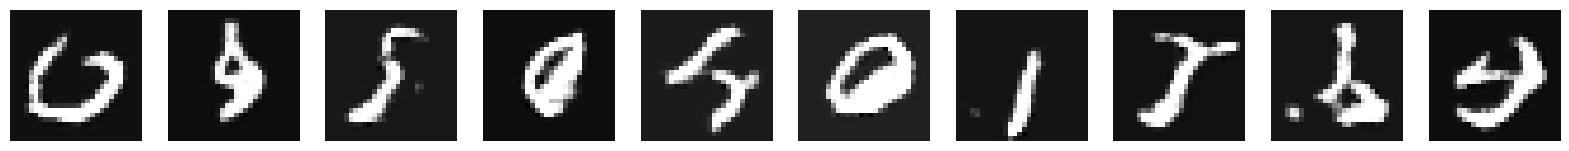

In [30]:
# Generate and visualize images
def generate_images(generator, n_images):
    noise = tf.random.normal([n_images, latent_dim])
    generated_images = generator.predict(noise, verbose=0)
    fig, axes = plt.subplots(1, n_images, figsize=(20, 4))
    for i, img in enumerate(generated_images):
        axes[i].imshow(img.squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()

print("Generating sample images...")
generate_images(generator, 10)

## Answers to GAN Questions

## 1. Transposed Convolution and its Use in Generators

### What is Transposed Convolution?
Transposed convolution (also called deconvolution) is an operation that performs the opposite of regular convolution. While regular convolution downsamples the input through striding, transposed convolution upsamples the input by applying learnable filters in a way that increases spatial dimensions.

### Why Use it in Generators?
- **Upsampling**: Generators need to transform a small latent vector (e.g., 100 dimensions) into a large image (e.g., 28×28 pixels). Transposed convolution progressively increases spatial dimensions.
- **Learnable Upsampling**: Unlike fixed upsampling methods (like bilinear interpolation), transposed convolution uses learnable parameters, allowing the network to discover optimal upsampling patterns.
- **Feature Hierarchy**: It enables the generator to build complex features hierarchically from simple patterns to detailed images.

## 2. LeakyReLU and Sigmoid Functions

### LeakyReLU
- **Function**: `f(x) = x if x > 0, else α*x` (α ≈ 0.2)
- **Purpose**: Prevents "dead neurons" by allowing small gradients for negative inputs
- **Usage**: In discriminator hidden layers for better gradient flow

### Sigmoid  
- **Function**: `f(x) = 1 / (1 + e^(-x))`
- **Purpose**: Outputs probabilities between 0 and 1
- **Usage**: In discriminator output layer for binary classification (real vs fake)

### Why These Choices?
- **LeakyReLU**: Maintains training stability in discriminator
- **Sigmoid**: Natural fit for binary classification task
- **Combination**: Proven effective for GAN discriminators